In [1]:
import os
os.getcwd()

'C:\\Users\\Suyash Y. Labhane\\Amazon_Prime_EDA_Project\\notebook'

In [2]:
import os
os.listdir("../data")

['credits.csv.zip', 'titles.csv.zip']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')   

In [4]:
titles = pd.read_csv("../data/titles.csv.zip")
credits = pd.read_csv("../data/credits.csv.zip")

In [5]:
# quick data check 
titles.head()
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [6]:
titles.shape

(9871, 15)

In [7]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [8]:
titles.describe()


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [9]:
titles.isnull().sum().sort_values(ascending=False)

seasons                 8514
age_certification       6487
tmdb_score              2082
imdb_votes              1031
imdb_score              1021
imdb_id                  667
tmdb_popularity          547
description              119
runtime                    0
title                      0
type                       0
id                         0
release_year               0
genres                     0
production_countries       0
dtype: int64

The dataset contains both numerical and categorical features with some missing values, which is common in OTT platform data.

In [10]:
credits.shape

(124235, 5)

In [11]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [12]:
credits.isnull().sum().sort_values(ascending=False)

character    16287
person_id        0
id               0
name             0
role             0
dtype: int64

In [13]:
titles['type'].value_counts()

type
MOVIE    8514
SHOW     1357
Name: count, dtype: int64

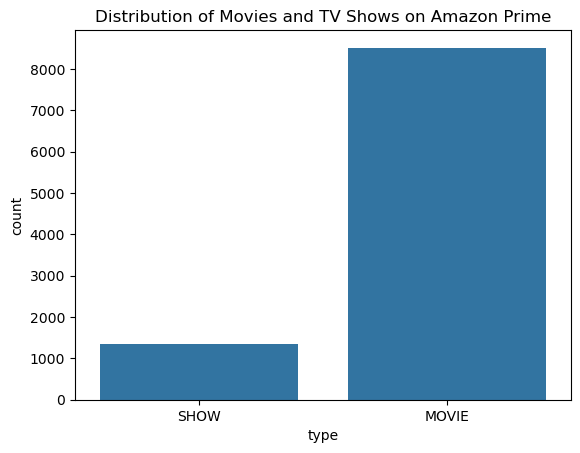

In [14]:
sns.countplot(x='type', data=titles)
plt.title("Distribution of Movies and TV Shows on Amazon Prime")
plt.show()

Amazon Prime hosts more movies compared to TV shows.

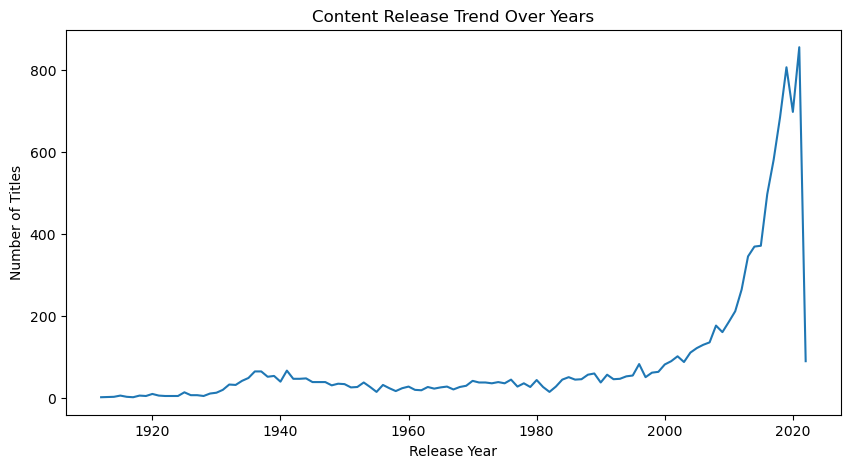

In [15]:
plt.figure(figsize=(10,5))
titles['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [16]:
#AGE CERTIFICATION / RATING ANALYSIS
titles['age_certification'].value_counts()

age_certification
R        1249
PG-13     588
PG        582
G         269
TV-MA     217
TV-14     188
TV-PG      91
TV-Y       78
TV-G       57
TV-Y7      52
NC-17      13
Name: count, dtype: int64

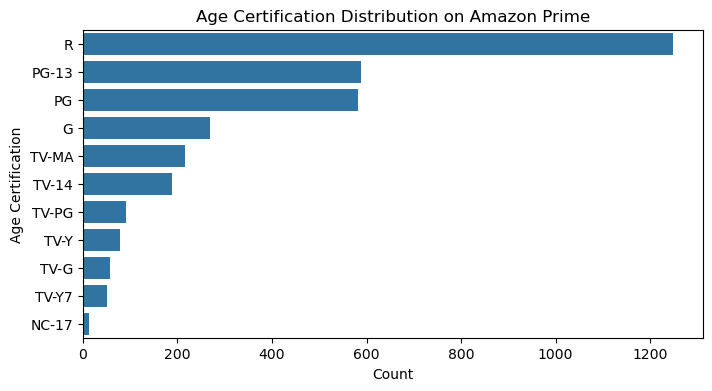

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(
    y='age_certification',
    data=titles,
    order=titles['age_certification'].value_counts().index
)
plt.title("Age Certification Distribution on Amazon Prime")
plt.xlabel("Count")
plt.ylabel("Age Certification")
plt.show()

Most content on Amazon Prime is targeted towards mature audiences, with TV-MA and R-rated content being prominent.

In [18]:
# IMDb SCORE DISTRIBUTION
titles['imdb_score'].describe()

count    8850.000000
mean        5.976395
std         1.343842
min         1.100000
25%         5.100000
50%         6.100000
75%         6.900000
max         9.900000
Name: imdb_score, dtype: float64

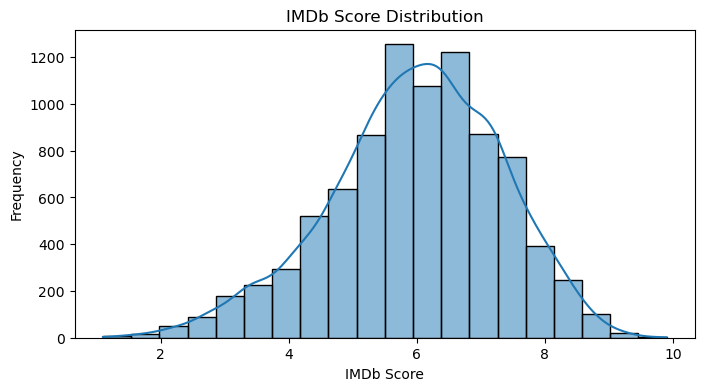

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(titles['imdb_score'], bins=20, kde=True)
plt.title("IMDb Score Distribution")
plt.xlabel("IMDb Score")
plt.ylabel("Frequency")
plt.show()

In [20]:
# Most titles have IMDb scores between 6 and 8, indicating generally positive audience reception.
titles['runtime'].describe()

count    9871.000000
mean       85.973052
std        33.512466
min         1.000000
25%        65.000000
50%        89.000000
75%       102.000000
max       549.000000
Name: runtime, dtype: float64

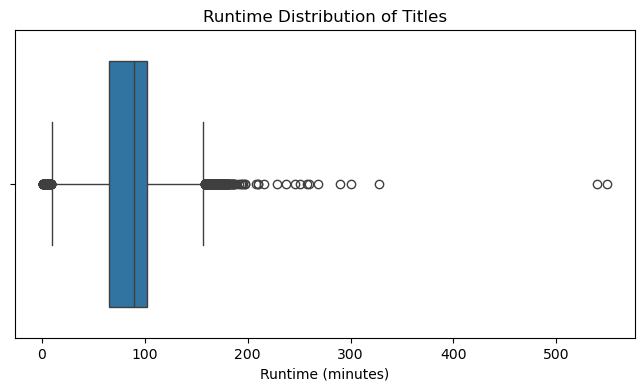

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x=titles['runtime'])
plt.title("Runtime Distribution of Titles")
plt.xlabel("Runtime (minutes)")
plt.show()

Most titles have runtimes under 120 minutes, while TV shows exhibit higher variability.

In [22]:
# GENRE ANALYSIS
titles['genres'].dropna().head()

0    ['comedy', 'family', 'animation', 'action', 'f...
1    ['action', 'drama', 'war', 'western', 'comedy'...
2                          ['romance', 'war', 'drama']
3                       ['comedy', 'drama', 'romance']
4                     ['thriller', 'drama', 'romance']
Name: genres, dtype: object

In [23]:
# Top Genres
from collections import Counter

genres_series = titles['genres'].dropna().str.split(',')
all_genres = Counter([g.strip() for sublist in genres_series for g in sublist])

top_genres = pd.DataFrame(all_genres.most_common(10), columns=['Genre', 'Count'])
top_genres

,Genre,Count
0,['drama',1720
1,'drama'],1145
2,'drama',991
3,['comedy',922
4,['thriller',912
5,['drama'],908
6,'romance'],775
7,'action',714
8,'comedy',713
9,['comedy'],686


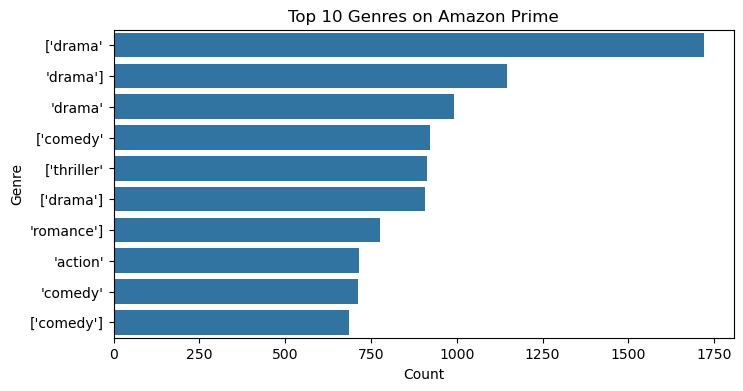

In [24]:
plt.figure(figsize=(8,4))
sns.barplot(x='Count', y='Genre', data=top_genres)
plt.title("Top 10 Genres on Amazon Prime")
plt.show()

Drama and Comedy are the most dominant genres on Amazon Prime, followed by Action and Thriller.

In [25]:
# COUNTRY-WISE CONTENT ANALYSIS
titles['production_countries'].value_counts().head(10)

production_countries
['US']    4810
['IN']    1048
[]         821
['GB']     667
['CA']     321
['JP']     172
['AU']     143
['XX']     120
['CN']     105
['FR']      93
Name: count, dtype: int64

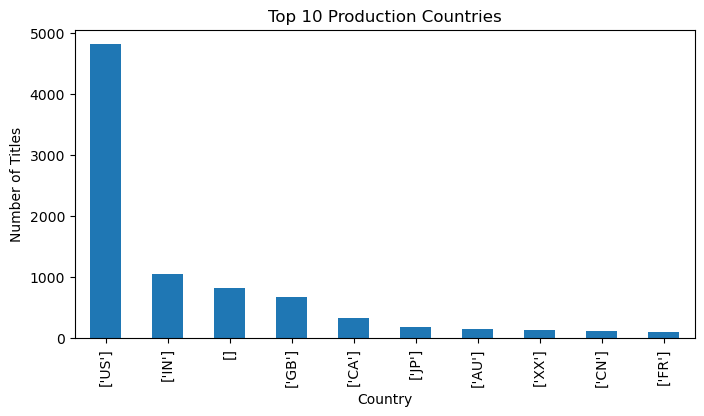

In [26]:
plt.figure(figsize=(8,4))
titles['production_countries'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Production Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

The majority of content on Amazon Prime is produced in the United States, followed by India and the United Kingdom.

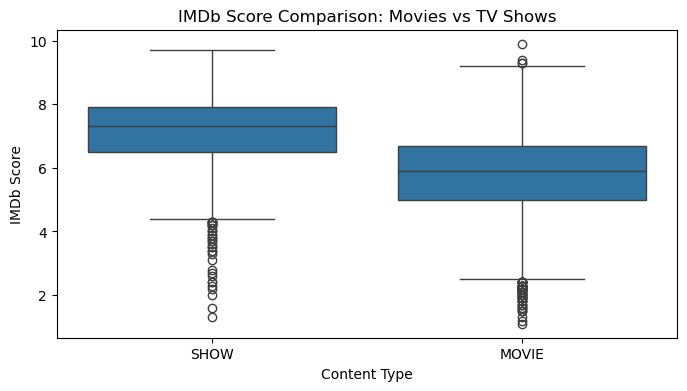

In [27]:
# MOVIES vs TV SHOWS – IMDb SCORE COMPARISON
plt.figure(figsize=(8,4))
sns.boxplot(x='type', y='imdb_score', data=titles)
plt.title("IMDb Score Comparison: Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("IMDb Score")
plt.show()

TV shows generally have slightly higher IMDb scores compared to movies, indicating stronger long-term audience engagement.

In [28]:
# MERGE TITLES & CREDITS DATASET
merged_df = pd.merge(titles, credits, on='id', how='left')
merged_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


In [29]:
# MOST FREQUENT ACTORS
merged_df['name'].value_counts().head(10)

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Joseph Kane             41
Gene Autry              40
Sam Newfield            38
Charles King            38
Nassar                  37
Herman Hack             35
Jay Chapman             34
Name: count, dtype: int64

Certain actors appear frequently across multiple Amazon Prime titles, indicating recurring collaborations.

In [30]:
# MOST COMMON ROLES (Actor / Director)
merged_df['role'].value_counts()

role
ACTOR       115952
DIRECTOR      8395
Name: count, dtype: int64

In [31]:
# FINAL SUMMARY TABLE
titles[['type','release_year','imdb_score','runtime']].describe()

,release_year,imdb_score,runtime
count,9871.000000,8850.000000,9871.000000
mean,2001.327221,5.976395,85.973052
std,25.810071,1.343842,33.512466
min,1912.000000,1.100000,1.000000
25%,1995.500000,5.100000,65.000000
50%,2014.000000,6.100000,89.000000
75%,2018.000000,6.900000,102.000000
max,2022.000000,9.900000,549.000000


## 🔍 Key Insights from Amazon Prime EDA

- Amazon Prime hosts a larger number of movies compared to TV shows.
- Content production has increased significantly after 2015.
- Drama and Comedy are the most dominant genres on the platform.
- Most titles target mature audiences.
- IMDb scores are generally between 6 and 8, indicating good content quality.
- The United States is the largest content-producing country.
- TV shows tend to receive higher IMDb ratings than movies.

## 📌 Business Impact

- Helps Amazon Prime understand audience preferences.
- Supports content recommendation and acquisition strategy.
- Enables better genre-based marketing.
- Assists in identifying high-performing content types.

## ✅ Conclusion

This exploratory data analysis provides valuable insights into Amazon Prime’s
content distribution, audience targeting, and performance trends.
Such insights can help streaming platforms optimize content strategy
and enhance user engagement.
